# Disaster Tweets Classification Using TinyBERT

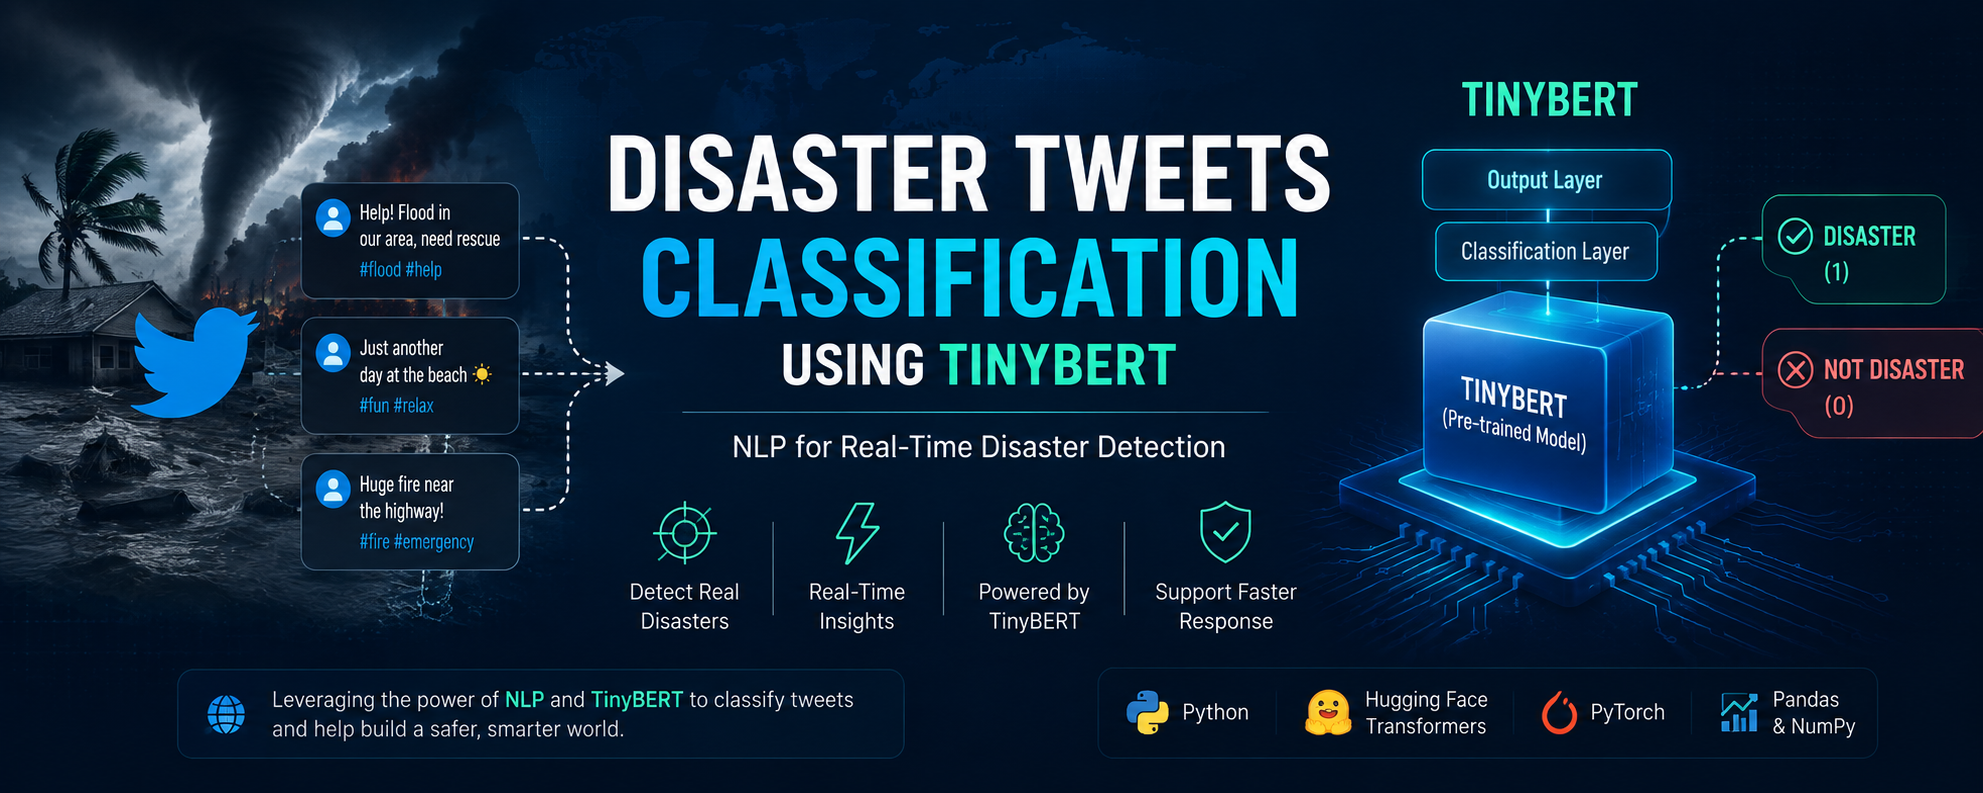

## Download the Data

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/laxmimerit/All-CSV-ML-Data-Files-Download/refs/heads/master/twitter_disaster_tweets.csv", usecols=['text', 'target'])
df.head()

,text,target
0,Our Deeds are the Reason of this #earthquake M...,1
1,Forest fire near La Ronge Sask. Canada,1
2,All residents asked to 'shelter in place' are ...,1
3,"13,000 people receive #wildfires evacuation or...",1
4,Just got sent this photo from Ruby #Alaska as ...,1


In [3]:
df.isnull().sum()

text      0
target    0
dtype: int64

In [4]:
df = df.sample(frac=1).reset_index(drop=True)
df.head()

,text,target
0,Listen to Landslide by Oh Wonder #SoundCloud h...,0
1,@LayLoveTournay @RyroTheUnaware [loud groaning...,0
2,the apocalypse is upon us,0
3,DRob collided into Dan Hughes while she was go...,0
4,I'm a disaster?? https://t.co/VCV73BUaCZ,0


In [5]:
df['target'].value_counts()

target
0    4342
1    3271
Name: count, dtype: int64

<Axes: >

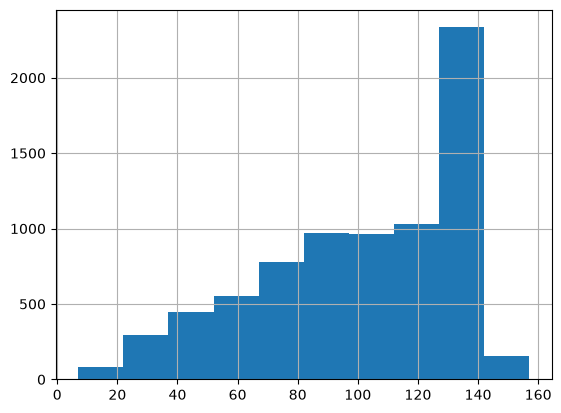

In [6]:
# context window in transformer -> 512 token
# 1 token ->3 char

df['text'].str.len().hist()

# Load Data with Hugging Face Datasets Library


In [7]:
df = df.rename(columns={'target':'label'})

In [8]:
from datasets import Dataset
dataset = Dataset.from_pandas(df)
dataset = dataset.train_test_split(test_size=0.2)

In [9]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 6090
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1523
    })
})

In [10]:
dataset['train'][0]

{'text': 'Washington Post - 4 dead dozens injured in Gaza blast near house leveled in summer war http://t.co/VjXa13n8Ap',
 'label': 1}

In [11]:
id2label = {0:'general', 1:'disaster'}
label2id = {'general':0, 'disaster':1}

# Data Tokenization

In [12]:
from transformers import AutoTokenizer
import torch

device = torch.device('cuda' if torch.cuda.is_available() else torch.device('cpu'))

model_ckpt = 'huawei-noah/TinyBERT_General_4L_312D'
tokenizer = AutoTokenizer.from_pretrained(model_ckpt, use_fast = True)

In [13]:
def tokenize(batch):
    temp = tokenizer(batch['text'], padding=True, truncation = True,max_length=100)
    return temp
dataset = dataset.map(tokenize, batched=True, batch_size = None)

Map: 100%|██████████| 1523/1523 [00:00<00:00, 3497.71 examples/s]


In [14]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 6090
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1523
    })
})

# Building Model Evaluation Function


In [15]:
!pip install evaluate
!pip install seqeval

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16281 sha256=c0a494a070587b1b7eb7b991fda9fc6f8be5903aab70f40cf0bffb2817a3cd7c
  Stored in directory: c:\users\uditya\appdata\local\pip\cache\wheels\bc\92\f0\243288f899c2eacdfa8c5f9aede4c71a9bad0ee26a01dc5ead
Successfully built seqeval


In [16]:
import evaluate
import numpy as np

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    return accuracy.compute(
        predictions=predictions,
        references=labels
    )

# Model Building and Training

In [17]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id,
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at huawei-noah/TinyBERT_General_4L_312D and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [18]:
model

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 312, padding_idx=0)
      (position_embeddings): Embedding(512, 312)
      (token_type_embeddings): Embedding(2, 312)
      (LayerNorm): LayerNorm((312,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-3): 4 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=312, out_features=312, bias=True)
              (key): Linear(in_features=312, out_features=312, bias=True)
              (value): Linear(in_features=312, out_features=312, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=312, out_features=312, bias=True)
              (LayerNorm): LayerNorm((312,), eps=1e-1

In [ ]:

from transformers import TrainingArguments, Trainer # Added Trainer here

args = TrainingArguments(
    output_dir="out",
    logging_dir="logs",
    report_to="none",
    logging_strategy="steps",
    logging_steps=50,

    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",   # Changed from evaluation_strategy
    save_strategy="epoch",
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
)

In [20]:
trainer.train()

  9%|▊         | 50/573 [00:33<04:48,  1.82it/s]

{'loss': 0.6637, 'grad_norm': 2.0786540508270264, 'learning_rate': 1.825479930191972e-05, 'epoch': 0.26}


 17%|█▋        | 100/573 [01:00<04:10,  1.89it/s]

{'loss': 0.5587, 'grad_norm': 2.2530975341796875, 'learning_rate': 1.6509598603839444e-05, 'epoch': 0.52}


 26%|██▌       | 150/573 [01:28<03:37,  1.94it/s]

...

                                                 
100%|██████████| 573/573 [05:28<00:00,  2.39it/s]

{'eval_loss': 0.42383870482444763, 'eval_accuracy': 0.8194353250164149, 'eval_runtime': 6.055, 'eval_samples_per_second': 251.526, 'eval_steps_per_second': 7.927, 'epoch': 3.0}


100%|██████████| 573/573 [05:29<00:00,  1.74it/s]

{'train_runtime': 329.5304, 'train_samples_per_second': 55.443, 'train_steps_per_second': 1.739, 'train_loss': 0.46924917943398575, 'epoch': 3.0}


TrainOutput(global_step=573, training_loss=0.46924917943398575, metrics={'train_runtime': 329.5304, 'train_samples_per_second': 55.443, 'train_steps_per_second': 1.739, 'total_flos': 42980020947360.0, 'train_loss': 0.46924917943398575, 'epoch': 3.0})

In [21]:
trainer.evaluate()

100%|██████████| 48/48 [00:05<00:00,  8.25it/s]


{'eval_loss': 0.42383870482444763,
 'eval_accuracy': 0.8194353250164149,
 'eval_runtime': 6.3565,
 'eval_samples_per_second': 239.598,
 'eval_steps_per_second': 7.551,
 'epoch': 3.0}

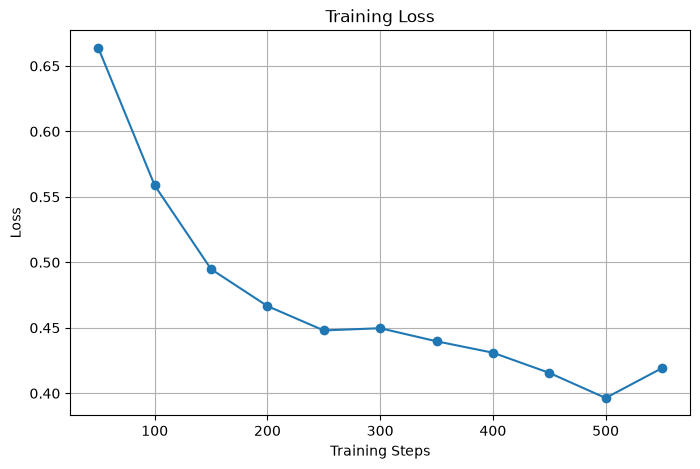

In [22]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history

train_loss = []
steps = []

for log in logs:
    if "loss" in log:
        train_loss.append(log["loss"])
        steps.append(log["step"])

plt.figure(figsize=(8,5))
plt.plot(steps, train_loss, marker="o")
plt.title("Training Loss")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

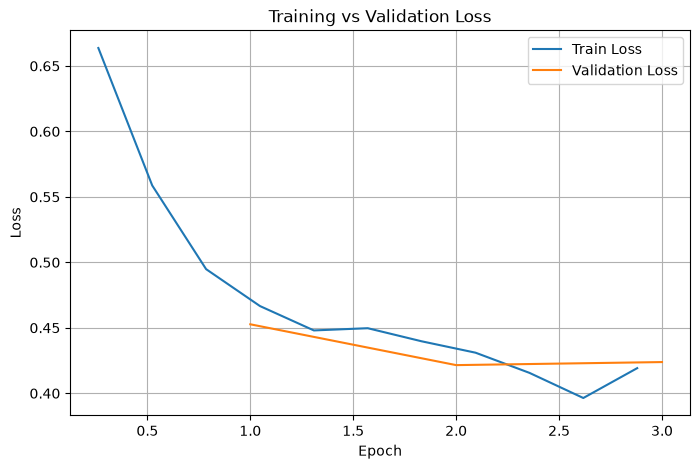

In [23]:
train_epochs = []
train_loss = []
eval_epochs = []
eval_loss = []

for log in trainer.state.log_history:
    if "loss" in log and "epoch" in log:
        train_epochs.append(log["epoch"])
        train_loss.append(log["loss"])

    if "eval_loss" in log:
        eval_epochs.append(log["epoch"])
        eval_loss.append(log["eval_loss"])

plt.figure(figsize=(8,5))
plt.plot(train_epochs, train_loss, label="Train Loss")
plt.plot(eval_epochs, eval_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Model Saving and Load for Inference

In [24]:
trainer.save_model('tinybert-disaster-tweet')

In [10]:
from transformers import pipeline
import torch
text  = [
    "BREAKING: A massive 6.8 magnitude earthquake just struck off the coast. Tsunami warnings issued for coastal areas! #Earthquake #News",
    "My laptop just crashed right before I saved my 20-page term paper. This is a total disaster 😭 #fml #help",
    "The wildfire is spreading rapidly due to high winds. Evacuation orders are now in place for Northern County residents. Be safe!",
    "That new Taylor Swift track is absolute fire! I have had it on repeat all morning long 🔥🎶",
    "Flash flood warnings active for downtown. Multiple roads are completely submerged. Do not attempt to drive through flooded areas.",
    "We are drowning in paperwork at the office today. Someone please rescue me from this boring meeting.",
    "Emergency crews are responding to a structural collapse at the industrial park. Avoid the area to let sirens through.",
    "I am burning up in this summer heat! The AC at the gym is broken and it feels like a literal oven in here.",
    "A major multi-vehicle accident has completely blocked all southbound lanes on Interstate 95. Expect severe traffic delays.",
    "My favorite character just got killed off in the season finale. I am emotionally destroyed right now. Why did they do this?!"
]


device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

classifier = pipeline('text-classification', model = 'tinybert-disaster-tweet', device = device)

df = classifier(text)

In [11]:
df

[{'label': 'disaster', 'score': 0.9027481079101562},
 {'label': 'general', 'score': 0.7186434268951416},
 {'label': 'disaster', 'score': 0.9023825526237488},
 {'label': 'general', 'score': 0.8390481472015381},
 {'label': 'disaster', 'score': 0.9028499126434326},
 {'label': 'general', 'score': 0.8125467896461487},
 {'label': 'disaster', 'score': 0.9024186134338379},
 {'label': 'general', 'score': 0.7888662219047546},
 {'label': 'disaster', 'score': 0.8984711170196533},
 {'label': 'general', 'score': 0.8884401917457581}]

In [12]:
import pandas as pd
data = pd.DataFrame(df)
data
data['Review'] = text
data['Predicted Sentiment Score'] = data['score']*100
data['Predicted Label'] = data['label']
data = data.drop(['label', 'score'], axis = 1)
data


,Review,Predicted Sentiment Score,Predicted Label
0,BREAKING: A massive 6.8 magnitude earthquake j...,90.274811,disaster
1,My laptop just crashed right before I saved my...,71.864343,general
2,The wildfire is spreading rapidly due to high ...,90.238255,disaster
3,That new Taylor Swift track is absolute fire! ...,83.904815,general
4,Flash flood warnings active for downtown. Mult...,90.284991,disaster
5,We are drowning in paperwork at the office tod...,81.254679,general
6,Emergency crews are responding to a structural...,90.241861,disaster
7,I am burning up in this summer heat! The AC at...,78.886622,general
8,A major multi-vehicle accident has completely ...,89.847112,disaster
9,My favorite character just got killed off in t...,88.844019,general


In [13]:
data.to_csv('tinybert_sentiment_results.csv', index=False)


## Push Model to AWS S3

In [ ]:
import boto3

s3 = boto3.client('s3')

bucket_name = 'disaster-classification-model-tinybert'

def create_bucket(bucket_name):
    response = s3.list_buckets()
    buckets = [buck['Name'] for buck in response['Buckets']]
    if bucket_name not in buckets:
        s3.create_bucket(Bucket=bucket_name)
        print("Bucket is Created")
    else:
        print("Bucket already exists in your account!!! Fell free to use it..")

create_bucket(bucket_name)

## Uploading the Model Folder to S3 Bucket  disaster-classification-model-tinybert/tinybert-disaster-tweet

In [ ]:
import os

import boto3
s3 = boto3.client('s3')

bucket_name = 'disaster-classification-model-tinybert'

def upload_directory(directory_path, s3_prefix):
    for root, dirs, files in os.walk(directory_path):
        for file in files:
            file_path = os.path.join(root, file).replace("\\", "/")
            relpath = os.path.relpath(file_path, directory_path)
            s3_key = os.path.join(s3_prefix, relpath).replace("\\", "/")

            s3.upload_file(file_path, bucket_name, s3_key)

upload_directory('tinybert-disaster-tweet', 'disaster-classification-model-tinybert/tinybert-disaster-tweet')